# City General Hospital — 30-day Readmission Prediction (MLP)

This notebook covers:
- EDA and data quality checks
- Unit normalization for blood pressure
- Class imbalance handling via oversampling
- MLP model training, evaluation, and threshold tuning
- Generating `predictions.csv` for the test set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils import resample

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:.6f}".format

In [2]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

train_df.head()

,patient_id,admission_date,age,gender,admission_type,discharge_destination,discharge_day_of_week,length_of_stay_days,charlson_comorbidity_index,prior_admissions_1yr,n_medications_discharge,insurance_type,glucose_level_mgdl,blood_pressure_systolic,sodium_meql,creatinine_mgdl,haemoglobin_gdl,readmitted_30d
0,PID10000,2020-01-01,24.000000,M,1,1,Tue,1.800000,7.000000,6.000000,2,Private,100.400000,112.300000,132.500000,0.820000,10.300000,0
1,PID10001,01/01/2020,73.000000,F,1,1,Thu,14.700000,2.000000,2.000000,14,Medicaid,114.300000,166.100000,154.300000,1.320000,10.600000,0
2,PID10002,01/01/2020,65.000000,F,1,3,Wed,10.600000,0.000000,0.000000,3,Private,106.400000,17.690000,133.800000,1.080000,13.600000,0
3,PID10003,2020-01-01,49.000000,M,2,1,Fri,9.100000,0.000000,0.000000,9,Medicaid,97.400000,131.900000,149.800000,0.640000,13.500000,0
4,PID10004,2020-01-02,49.000000,F,1,1,Thu,7.500000,0.000000,0.000000,7,Medicare,NaN,137.300000,142.400000,2.260000,11.900000,0


## Basic overview

In [3]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Target balance:\n", train_df["readmitted_30d"].value_counts())

Train shape: (3800, 18)
Test shape: (950, 17)
Target balance:
 readmitted_30d
0    3458
1     342
Name: count, dtype: int64


## Class imbalance

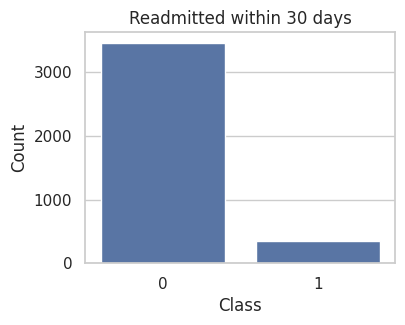

In [4]:
plt.figure(figsize=(4,3))
ax = sns.countplot(x="readmitted_30d", data=train_df)
ax.set_title("Readmitted within 30 days")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.show()

## Blood pressure unit normalization

Values below 50 are treated as kPa and converted to mmHg.

Values < 50: 473


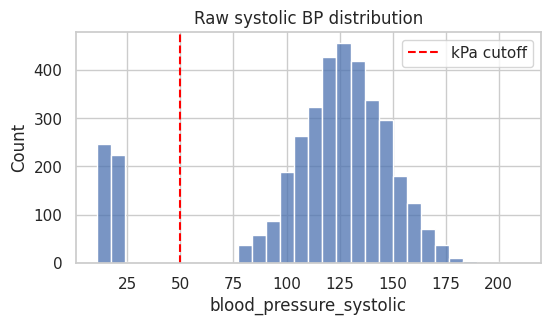

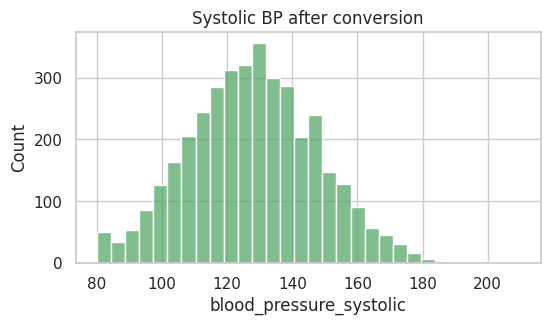

In [5]:
KPA_TO_MMHG = 7.50062

bp_raw = train_df["blood_pressure_systolic"].astype(float)
print("Values < 50:", (bp_raw < 50).sum())

plt.figure(figsize=(6,3))
sns.histplot(bp_raw, bins=30, color="#4c72b0")
plt.axvline(50, color="red", linestyle="--", label="kPa cutoff")
plt.title("Raw systolic BP distribution")
plt.legend()
plt.show()

bp_fixed = bp_raw.copy()
mask = bp_fixed < 50
bp_fixed.loc[mask] = bp_fixed.loc[mask] * KPA_TO_MMHG

plt.figure(figsize=(6,3))
sns.histplot(bp_fixed, bins=30, color="#55a868")
plt.title("Systolic BP after conversion")
plt.show()

## Missing values

In [6]:
missing = train_df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

glucose_level_mgdl    673
dtype: int64

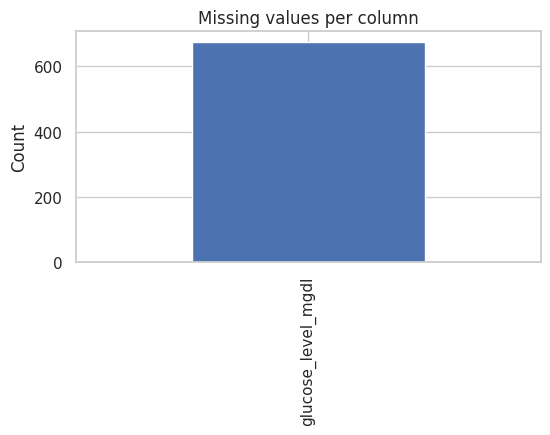

In [7]:
plt.figure(figsize=(6,3))
missing.plot(kind="bar")
plt.title("Missing values per column")
plt.ylabel("Count")
plt.show()

## Boxplot after settling outliers

## Preprocessing helpers

In [8]:
from dataclasses import dataclass

@dataclass
class PreprocessConfig:
    bp_kpa_threshold: float = 50.0
    date_column: str = "admission_date"
    target_column: str = "readmitted_30d"
    id_column: str = "patient_id"

cfg = PreprocessConfig()


def fix_blood_pressure(df, cfg):
    df = df.copy()
    bp = df["blood_pressure_systolic"].astype(float)
    mask = bp < cfg.bp_kpa_threshold
    df.loc[mask, "blood_pressure_systolic"] = bp.loc[mask] * KPA_TO_MMHG
    return df


def parse_admission_date(df, cfg):
    df = df.copy()
    dates = pd.to_datetime(df[cfg.date_column], errors="coerce")
    df["admission_year"] = dates.dt.year
    df["admission_month"] = dates.dt.month
    df["admission_day"] = dates.dt.day
    df.drop(columns=[cfg.date_column], inplace=True)
    return df


def prepare_features(df, cfg):
    df = fix_blood_pressure(df, cfg)
    df = parse_admission_date(df, cfg)
    if "age" in df.columns:
        df.loc[df["age"] > 120, "age"] = np.nan
    for col in ["admission_type", "discharge_destination"]:
        if col in df.columns:
            df[col] = df[col].astype("Int64").astype(str)
    return df


def oversample_minority(X, y):
    data = X.copy()
    data["_target"] = y.values

    majority = data[data["_target"] == 0]
    minority = data[data["_target"] == 1]

    if len(minority) == 0 or len(majority) == 0:
        return X, y

    minority_upsampled = resample(
        minority,
        replace=True,
        n_samples=len(majority),
        random_state=42,
    )

    balanced = pd.concat([majority, minority_upsampled]).sample(frac=1.0, random_state=42)
    y_bal = balanced.pop("_target").astype(int)
    return balanced, y_bal

def compute_outlier_bounds(df, exclude_cols):
    bounds = {}
    for col in df.columns:
        if col in exclude_cols:
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            bounds[col] = (df[col].quantile(0.01), df[col].quantile(0.99))
    return bounds

def apply_outlier_bounds(df, bounds):
    df = df.copy()
    for col, (low, high) in bounds.items():
        if col in df.columns:
            df[col] = df[col].clip(lower=low, upper=high)
    return df

Age == 999 count: 12


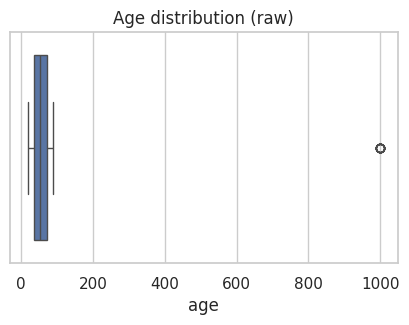

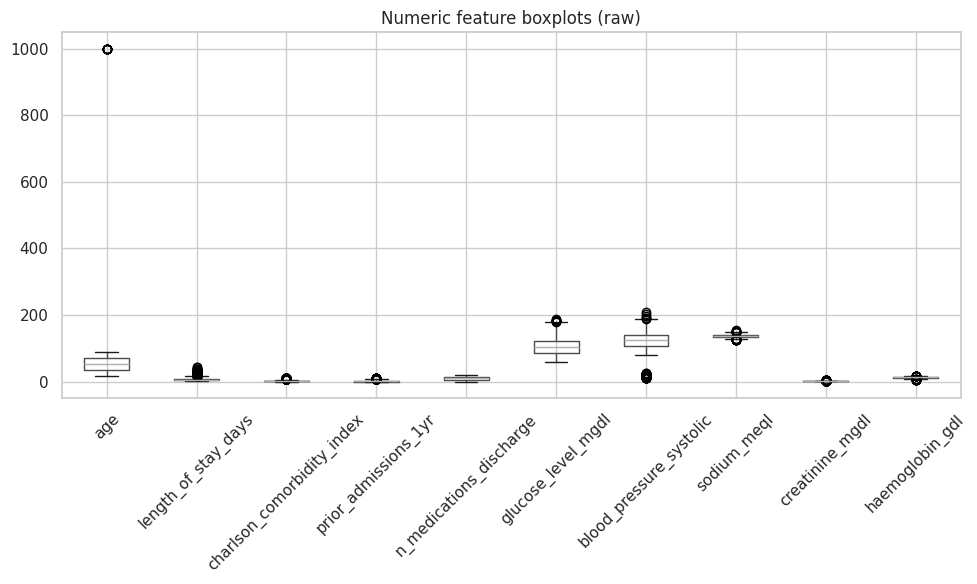

In [9]:
# Quick outlier scan for age
print("Age == 999 count:", (train_df["age"] == 999).sum())

plt.figure(figsize=(5,3))
sns.boxplot(x=train_df["age"], color="#4c72b0")
plt.title("Age distribution (raw)")
plt.show()

# Boxplots for key numeric features
numeric_cols = [
    "age",
    "length_of_stay_days",
    "charlson_comorbidity_index",
    "prior_admissions_1yr",
    "n_medications_discharge",
    "glucose_level_mgdl",
    "blood_pressure_systolic",
    "sodium_meql",
    "creatinine_mgdl",
    "haemoglobin_gdl",
]

plt.figure(figsize=(10,6))
train_df[numeric_cols].boxplot(rot=45)
plt.title("Numeric feature boxplots (raw)")
plt.tight_layout()
plt.show()

## Outlier checks

We checked numeric columns for extreme values. Age had sentinel values (e.g., 999), which are not realistic and are treated as missing.

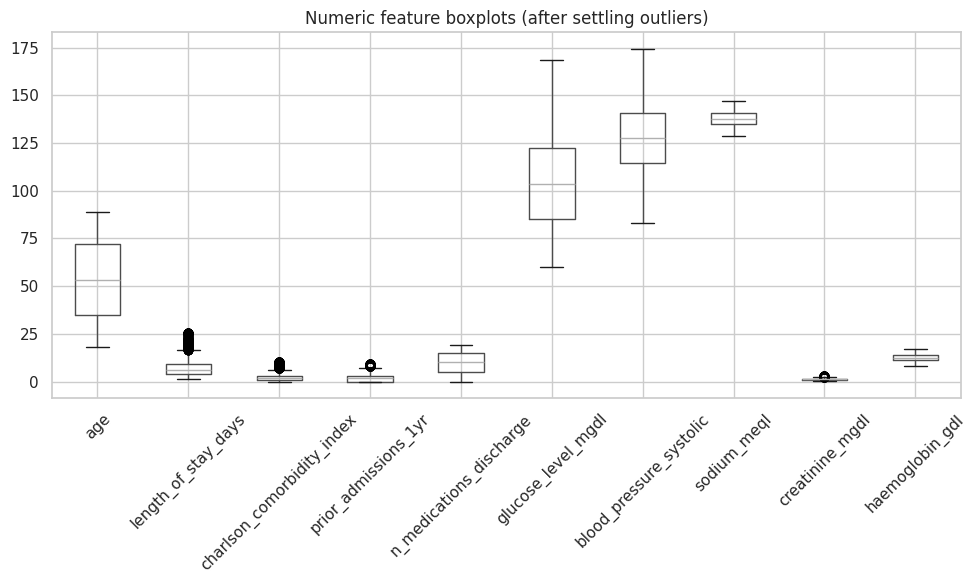

In [10]:
# Apply age fix and outlier capping for visualization
clean_for_plot = prepare_features(train_df, cfg)

exclude_cols = [cfg.id_column, cfg.target_column, "admission_type", "discharge_destination", "gender", "discharge_day_of_week", "insurance_type"]
bounds = compute_outlier_bounds(clean_for_plot, exclude_cols=exclude_cols)
clean_for_plot = apply_outlier_bounds(clean_for_plot, bounds)

numeric_cols = [
    "age",
    "length_of_stay_days",
    "charlson_comorbidity_index",
    "prior_admissions_1yr",
    "n_medications_discharge",
    "glucose_level_mgdl",
    "blood_pressure_systolic",
    "sodium_meql",
    "creatinine_mgdl",
    "haemoglobin_gdl",
]

plt.figure(figsize=(10,6))
clean_for_plot[numeric_cols].boxplot(rot=45)
plt.title("Numeric feature boxplots (after settling outliers)")
plt.tight_layout()
plt.show()

## Train/validation split and pipeline

In [11]:
model_df = prepare_features(train_df, cfg)

X = model_df.drop(columns=[cfg.target_column])
y = model_df[cfg.target_column].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

exclude_cols = [cfg.id_column, "admission_type", "discharge_destination", "gender", "discharge_day_of_week", "insurance_type"]
bounds = compute_outlier_bounds(X_train, exclude_cols=exclude_cols)
X_train = apply_outlier_bounds(X_train, bounds)
X_val = apply_outlier_bounds(X_val, bounds)


X_train_bal, y_train_bal = oversample_minority(X_train, y_train)

print("Before balancing: ", y_train.value_counts())
print("After balancing:", y_train_bal.value_counts())

categorical_cols = (
    X_train_bal.select_dtypes(include=["object", "string", "category"])
    .columns
    .difference([cfg.id_column])
    .tolist()
)

numeric_cols = [c for c in X_train_bal.columns if c not in categorical_cols + [cfg.id_column]]

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ]
)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32, 16),
    activation="relu",
    alpha=1e-4,
    max_iter=300,
    random_state=42,
)

pipeline = Pipeline(steps=[("preprocess", preprocessor), ("model", mlp)])


Before balancing:  readmitted_30d
0    2766
1     274
Name: count, dtype: int64
After balancing: _target
1    2766
0    2766
Name: count, dtype: int64


## Fit model and evaluate

In [12]:
pipeline.fit(
    X_train_bal.drop(columns=[cfg.id_column]),
    y_train_bal,
)

val_probs = pipeline.predict_proba(X_val.drop(columns=[cfg.id_column]))[:, 1]

roc_auc = roc_auc_score(y_val, val_probs)
pr_auc = average_precision_score(y_val, val_probs)

thresholds = np.linspace(0.05, 0.95, 19)
best_t, best_f1 = 0.5, -1
for t in thresholds:
    preds = (val_probs >= t).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_f1, best_t = f1, t

val_preds = (val_probs >= best_t).astype(int)

print(f"ROC AUC: {roc_auc:.3f}")
print(f"PR AUC: {pr_auc:.3f}")
print(f"Best F1: {best_f1:.3f} at threshold {best_t:.2f}")
print(f"Precision: {precision_score(y_val, val_preds):.3f}")
print(f"Recall: {recall_score(y_val, val_preds):.3f}")

ROC AUC: 0.908
PR AUC: 0.625
Best F1: 0.538 at threshold 0.45
Precision: 0.627
Recall: 0.471


## MLP loss curve

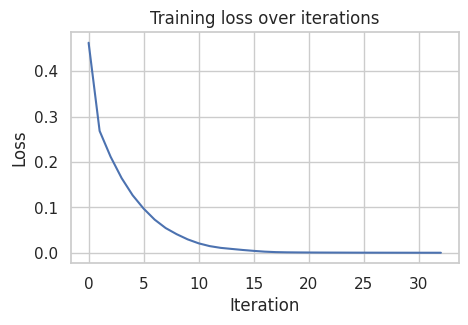

In [13]:
plt.figure(figsize=(5,3))
plt.plot(pipeline.named_steps["model"].loss_curve_)
plt.title("Training loss over iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

## ROC and Precision-Recall curves

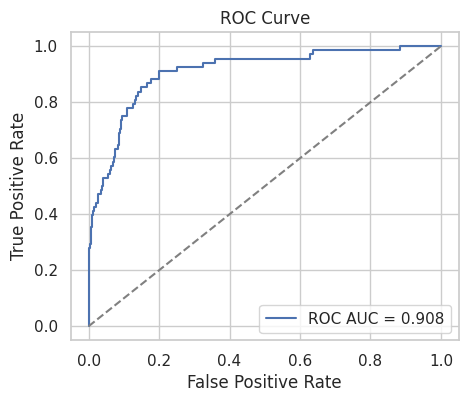

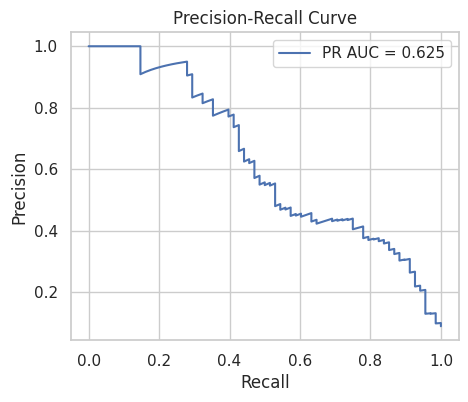

In [14]:
fpr, tpr, _ = roc_curve(y_val, val_probs)
prec, rec, _ = precision_recall_curve(y_val, val_probs)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

plt.figure(figsize=(5,4))
plt.plot(rec, prec, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## Confusion matrix at selected threshold

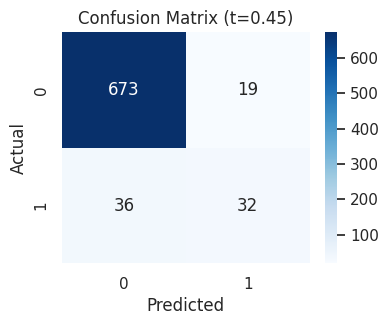

In [15]:
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix (t={best_t:.2f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Train final model and generate predictions.csv

In [16]:
full_df = prepare_features(train_df, cfg)
X_full = full_df.drop(columns=[cfg.target_column])
y_full = full_df[cfg.target_column].astype(int)

exclude_cols = [cfg.id_column, "admission_type", "discharge_destination", "gender", "discharge_day_of_week", "insurance_type"]
bounds = compute_outlier_bounds(X_full, exclude_cols=exclude_cols)
X_full = apply_outlier_bounds(X_full, bounds)

X_full_bal, y_full_bal = oversample_minority(X_full, y_full)

pipeline.fit(
    X_full_bal.drop(columns=[cfg.id_column]),
    y_full_bal,
)

clean_test = prepare_features(test_df, cfg)
probs = pipeline.predict_proba(clean_test.drop(columns=[cfg.id_column]))[:, 1]

preds = pd.DataFrame({
    "patient_id": clean_test[cfg.id_column],
    "readmitted_30d": (probs >= 0.70).astype(int),
})

preds.to_csv("../predictions.csv", index=False)
preds.head()

,patient_id,readmitted_30d
0,PID10000,0
1,PID10001,0
2,PID10002,0
3,PID10003,0
4,PID10004,0
